<a href="https://colab.research.google.com/github/Nazarsiska735/Artificial-/blob/main/lab2_fixed_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 2
## Полносвязная нейронная сеть (CIFAR-10)

Архитектура: `Вход (3072) → FC1 → ReLU → FC2 → Softmax → Выход (10 классов)`


## 0. Импорт

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os, pickle, tarfile, urllib.request
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

def rel_error(x, y):
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

print("Импорт выполнен ✓")


Импорт выполнен ✓


## 1. Загрузка CIFAR-10

In [ ]:
cifar_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
cifar_tar = 'cifar-10-python.tar.gz'
cifar_dir = 'cifar-10-batches-py'

if not os.path.exists(cifar_dir):
    if not os.path.exists(cifar_tar):
        print("Скачиваем CIFAR-10...")
        urllib.request.urlretrieve(cifar_url, cifar_tar)
    with tarfile.open(cifar_tar, 'r:gz') as t:
        t.extractall('.')
    print("Готово ✓")
else:
    print("CIFAR-10 уже загружен ✓")

def load_cifar_batch(filename):
    with open(filename, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    X = d[b'data'].reshape(-1, 3, 32, 32).transpose(0,2,3,1)
    y = np.array(d[b'labels'])
    return X, y

def load_CIFAR10(root):
    Xs, ys = [], []
    for i in range(1, 6):
        X, y = load_cifar_batch(os.path.join(root, f'data_batch_{i}'))
        Xs.append(X); ys.append(y)
    X_train = np.concatenate(Xs)
    y_train = np.concatenate(ys)
    X_test, y_test = load_cifar_batch(os.path.join(root, 'test_batch'))
    return X_train, y_train, X_test, y_test

X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_CIFAR10(cifar_dir)
print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")


Скачиваем CIFAR-10...


/tmp/ipykernel_1678/433657216.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('.')


Готово ✓
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


## 2. Предобработка данных

In [ ]:
num_train = 49000
num_val   = 1000
num_test  = 1000

X_train = X_train_raw[:num_train].reshape(num_train, -1).astype(np.float64)
y_train = y_train_raw[:num_train]
X_val   = X_train_raw[num_train:num_train+num_val].reshape(num_val, -1).astype(np.float64)
y_val   = y_train_raw[num_train:num_train+num_val]
X_test  = X_test_raw[:num_test].reshape(num_test, -1).astype(np.float64)
y_test  = y_test_raw[:num_test]

mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val   -= mean_image
X_test  -= mean_image

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Предобработка выполнена ✓")


Train: (49000, 3072), Val: (1000, 3072), Test: (1000, 3072)
Предобработка выполнена ✓


## 3. Реализация класса TwoLayerNet

In [26]:
class TwoLayerNet:
    # Двухслойная полносвязная нейронная сеть.
    # Архитектура: FC -> ReLU -> FC -> Softmax
    # Loss: cross-entropy + L2 регуляризация

    def __init__(self, input_size, hidden_size, output_size, std=1e-4):
        self.params = {}
        self.params['W1'] = std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def loss(self, X, y=None, reg=0.0):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        N, D   = X.shape

        # Прямой проход
        z1     = X.dot(W1) + b1
        a1     = np.maximum(0, z1)
        scores = a1.dot(W2) + b2

        if y is None:
            return scores

        # Loss
        scores -= scores.max(axis=1, keepdims=True)
        exp_s   = np.exp(scores)
        probs   = exp_s / exp_s.sum(axis=1, keepdims=True)
        correct_log_probs = -np.log(probs[np.arange(N), y])
        loss  = correct_log_probs.mean()
        loss += reg * (np.sum(W1**2) + np.sum(W2**2))

        # Обратный проход
        grads = {}
        dscores = probs.copy()
        dscores[np.arange(N), y] -= 1
        dscores /= N
        grads['W2'] = a1.T.dot(dscores) + 2 * reg * W2
        grads['b2'] = dscores.sum(axis=0)
        da1 = dscores.dot(W2.T)
        dz1 = da1 * (z1 > 0)
        grads['W1'] = X.T.dot(dz1) + 2* reg * W1
        grads['b1'] = dz1.sum(axis=0)

        return loss, grads

    def train(self, X, y, X_val, y_val,
              learning_rate=1e-3, learning_rate_decay=0.95,
              reg=5e-6, num_iters=100,
              batch_size=200, verbose=False):
        N = X.shape[0]
        iterations_per_epoch = max(N // batch_size, 1)
        loss_history      = []
        train_acc_history = []
        val_acc_history   = []

        for it in range(num_iters):
            batch_idx = np.random.choice(N, batch_size, replace=False)
            X_batch   = X[batch_idx]
            y_batch   = y[batch_idx]
            loss, grads = self.loss(X_batch, y=y_batch, reg=reg)
            loss_history.append(loss)
            for param in ['W1', 'b1', 'W2', 'b2']:
                self.params[param] -= learning_rate * grads[param]
            if verbose and it % 100 == 0:
                print(f'iter {it:5d}/{num_iters}: loss = {loss:.4f}')
            if it % iterations_per_epoch == 0:
                train_acc = (self.predict(X_batch) == y_batch).mean()
                val_acc   = (self.predict(X_val)   == y_val).mean()
                train_acc_history.append(train_acc)
                val_acc_history.append(val_acc)
                learning_rate *= learning_rate_decay

        return {
            'loss_history':      loss_history,
            'train_acc_history': train_acc_history,
            'val_acc_history':   val_acc_history,
        }

    def predict(self, X):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        a1     = np.maximum(0, X.dot(W1) + b1)
        scores = a1.dot(W2) + b2
        return np.argmax(scores, axis=1)

print("Класс TwoLayerNet реализован ✓")


Класс TwoLayerNet реализован ✓


2*2## 4. Проверка на модельных данных

### 4.1 Прямой проход: scores

In [27]:
input_size  = 4
hidden_size = 10
num_classes = 3
num_inputs  = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

scores = net.loss(X)
print('Your scores:')
print(scores)
print()

correct_scores = np.asarray([
    [-0.81233741, -1.27654624, -0.70335995],
    [-0.17129677, -1.18803311, -0.47310444],
    [-0.51590475, -1.01354314, -0.8504215 ],
    [-0.15419291, -0.48629638, -0.52901952],
    [-0.00618733, -0.12435261, -0.15226949]])
print('Correct scores:')
print(correct_scores)
print()
diff = np.sum(np.abs(scores - correct_scores))
print(f'Difference: {diff:.2e}')
if diff < 1e-6:
    print("✓ Прямой проход (scores) реализован верно!")
else:
    print("✗ Есть ошибка в прямом проходе")


Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference: 3.68e-08
✓ Прямой проход (scores) реализован верно!


### 4.2 Прямой проход: loss

In [28]:
# Пересоздаём сеть с теми же весами
net = init_toy_model()
X, y = init_toy_data()


print("W1 первые 3 значения:", net.params['W1'].flatten()[:3])
# Должно быть: [0.12240... -0.09876... ...]

loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133
diff = np.abs(loss - correct_loss)
print(f'Your loss:    {loss:.11f}')
print(f'Correct loss: {correct_loss:.11f}')
print(f'Difference:   {diff:.2e}')

# Теперь считаем loss
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print(f'Your loss:    {loss:.11f}')
print(f'Correct loss: {correct_loss:.11f}')
diff = np.abs(loss - correct_loss)
print(f'Difference:   {diff:.2e}')
if diff < 1e-12:
    print("✓ Loss реализован верно!")
else:
    print("✗ Есть ошибка в вычислении loss")

W1 первые 3 значения: [0.17640523 0.04001572 0.0978738 ]
Your loss:    1.30378789133
Correct loss: 1.30378789133
Difference:   1.80e-13
Your loss:    1.30378789133
Correct loss: 1.30378789133
Difference:   1.80e-13
✓ Loss реализован верно!


### 4.3 Обратный проход: проверка градиентов

In [29]:
def eval_numerical_gradient(f, x, verbose=False, h=1e-5):
    fx   = f(x)
    grad = np.zeros_like(x)
    it   = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix     = it.multi_index
        oldval = x[ix]
        x[ix]  = oldval + h; fxph = f(x)
        x[ix]  = oldval - h; fxmh = f(x)
        x[ix]  = oldval
        grad[ix] = (fxph - fxmh) / (2 * h)
        it.iternext()
    return grad

loss, grads = net.loss(X, y, reg=0.05)

print("Проверка градиентов (ошибка должна быть < 1e-8):")
for param_name in ['W1', 'b1', 'W2', 'b2']:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    err    = rel_error(grad_num, grads[param_name])
    status = "✓" if err < 1e-7 else "✗"
    print(f'  {status} {param_name}: max relative error = {err:.2e}')


Проверка градиентов (ошибка должна быть < 1e-8):
  ✓ W1: max relative error = 3.56e-09
  ✓ b1: max relative error = 2.74e-09
  ✓ W2: max relative error = 3.44e-09
  ✓ b2: max relative error = 4.45e-11


## 5. Обучение на смоделированных данных

Final training loss: 0.015635
(Ожидаем loss < 0.02)


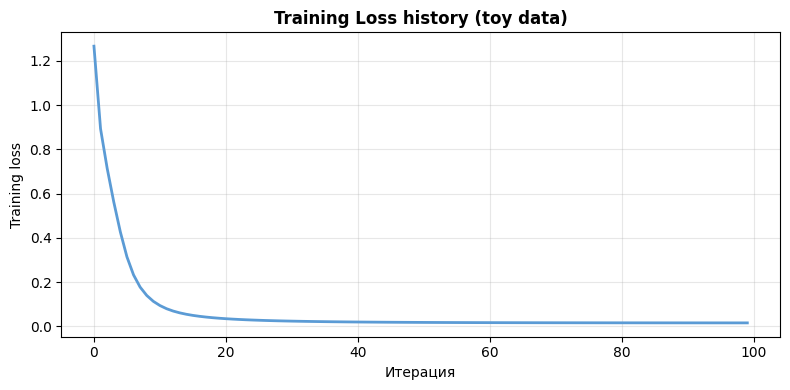

✓ Сеть успешно переобучилась на малых данных!


In [30]:
net = init_toy_model()
X, y = init_toy_data()

stats = net.train(X, y, X, y,
                  learning_rate=1e-1, reg=5e-6,
                  num_iters=100, batch_size=5,
                  verbose=False)

print(f'Final training loss: {stats["loss_history"][-1]:.6f}')
print(f'(Ожидаем loss < 0.02)')

plt.figure(figsize=(8, 4))
plt.plot(stats['loss_history'], color='#5B9BD5', lw=2)
plt.xlabel('Итерация'); plt.ylabel('Training loss')
plt.title('Training Loss history (toy data)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

if stats['loss_history'][-1] < 0.02:
    print("✓ Сеть успешно переобучилась на малых данных!")


## 6. Обучение на CIFAR-10

### 6.1 Базовое обучение

In [31]:
input_size  = 32 * 32 * 3
hidden_size = 50
num_classes = 10

net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
                  num_iters=1000, batch_size=200,
                  learning_rate=1e-4, learning_rate_decay=0.95,
                  reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print(f'\nValidation accuracy: {val_acc:.4f}')
print('(Ожидаем примерно 0.29)')


iter     0/1000: loss = 2.3030
iter   100/1000: loss = 2.3025
iter   200/1000: loss = 2.2943
iter   300/1000: loss = 2.2487
iter   400/1000: loss = 2.2355
iter   500/1000: loss = 2.1352
iter   600/1000: loss = 2.0873
iter   700/1000: loss = 2.0164
iter   800/1000: loss = 2.0234
iter   900/1000: loss = 1.9687

Validation accuracy: 0.2930
(Ожидаем примерно 0.29)


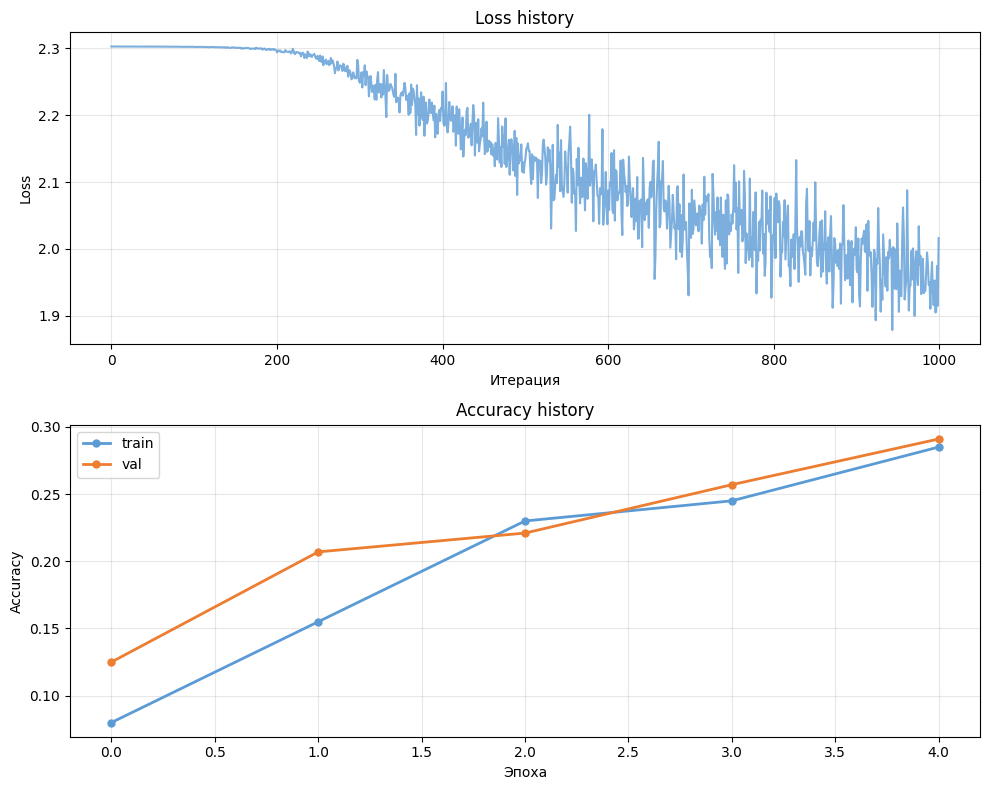

In [32]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(stats['loss_history'], color='#5B9BD5', lw=1.5, alpha=0.8)
ax1.set_title('Loss history'); ax1.set_xlabel('Итерация'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(stats['train_acc_history'], '-o', label='train', color='#5B9BD5', lw=2, ms=5)
ax2.plot(stats['val_acc_history'],   '-o', label='val',   color='#ED7D31', lw=2, ms=5)
ax2.set_title('Accuracy history'); ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


### 6.2 Подбор гиперпараметров

In [34]:
best_val_acc = -1
best_net     = None
best_params  = {}

learning_rates  = [1e-3, 5e-3]
regularizations = [0.1, 0.25]
hidden_sizes    = [128, 256]

print(f"{'hidden':>8s} {'lr':>8s} {'reg':>8s} {'train_acc':>10s} {'val_acc':>10s}")
print("-" * 55)

for hs in hidden_sizes:
    for lr in learning_rates:
        for reg in regularizations:
            net_tmp = TwoLayerNet(input_size, hs, num_classes)
            stats_tmp = net_tmp.train(
                X_train, y_train, X_val, y_val,
                num_iters=500, batch_size=256,
                learning_rate=lr, learning_rate_decay=0.95,
                reg=reg, verbose=False
            )
            train_acc = stats_tmp['train_acc_history'][-1]
            val_acc   = (net_tmp.predict(X_val) == y_val).mean()
            print(f"{hs:>8d} {lr:>8.0e} {reg:>8.2f} {train_acc:>10.4f} {val_acc:>10.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_net     = net_tmp
                best_params  = {'hidden_size': hs, 'lr': lr, 'reg': reg}

print(f"\nЛучшие параметры: {best_params}")
print(f"Лучшая val accuracy: {best_val_acc:.4f}")


  hidden       lr      reg  train_acc    val_acc
-------------------------------------------------------
     128    1e-03     0.10     0.4492     0.4510
     128    1e-03     0.25     0.4570     0.4510


/tmp/ipykernel_1678/2790931034.py:30: RuntimeWarning: divide by zero encountered in log
  correct_log_probs = -np.log(probs[np.arange(N), y])


     128    5e-03     0.10     0.1250     0.0740
     128    5e-03     0.25     0.1289     0.0820
     256    1e-03     0.10     0.4922     0.4470
     256    1e-03     0.25     0.5117     0.4580
     256    5e-03     0.10     0.1250     0.0790
     256    5e-03     0.25     0.1250     0.1430

Лучшие параметры: {'hidden_size': 256, 'lr': 0.001, 'reg': 0.25}
Лучшая val accuracy: 0.4580


### 6.3 Финальное обучение лучшей модели

In [35]:
final_net = TwoLayerNet(input_size, best_params['hidden_size'], num_classes)

final_stats = final_net.train(
    X_train, y_train, X_val, y_val,
    num_iters=3000, batch_size=256,
    learning_rate=best_params['lr'],
    learning_rate_decay=0.95,
    reg=best_params['reg'],
    verbose=True
)

val_acc_final  = (final_net.predict(X_val)  == y_val).mean()
test_acc_final = (final_net.predict(X_test) == y_test).mean()
print(f'\nVal  accuracy: {val_acc_final:.4f}')
print(f'Test accuracy: {test_acc_final:.4f}')


iter     0/3000: loss = 2.3045
iter   100/3000: loss = 1.9570
iter   200/3000: loss = 1.7667
iter   300/3000: loss = 1.6773
iter   400/3000: loss = 1.5624
iter   500/3000: loss = 1.5494
iter   600/3000: loss = 1.5009
iter   700/3000: loss = 1.6188
iter   800/3000: loss = 1.4861
iter   900/3000: loss = 1.5130
iter  1000/3000: loss = 1.5148
iter  1100/3000: loss = 1.5423
iter  1200/3000: loss = 1.5547
iter  1300/3000: loss = 1.5193
iter  1400/3000: loss = 1.3317
iter  1500/3000: loss = 1.3555
iter  1600/3000: loss = 1.4497
iter  1700/3000: loss = 1.4405
iter  1800/3000: loss = 1.3115
iter  1900/3000: loss = 1.3753
iter  2000/3000: loss = 1.2841
iter  2100/3000: loss = 1.4132
iter  2200/3000: loss = 1.4139
iter  2300/3000: loss = 1.3752
iter  2400/3000: loss = 1.2006
iter  2500/3000: loss = 1.3313
iter  2600/3000: loss = 1.2610
iter  2700/3000: loss = 1.2964
iter  2800/3000: loss = 1.3011
iter  2900/3000: loss = 1.2616

Val  accuracy: 0.5160
Test accuracy: 0.5380


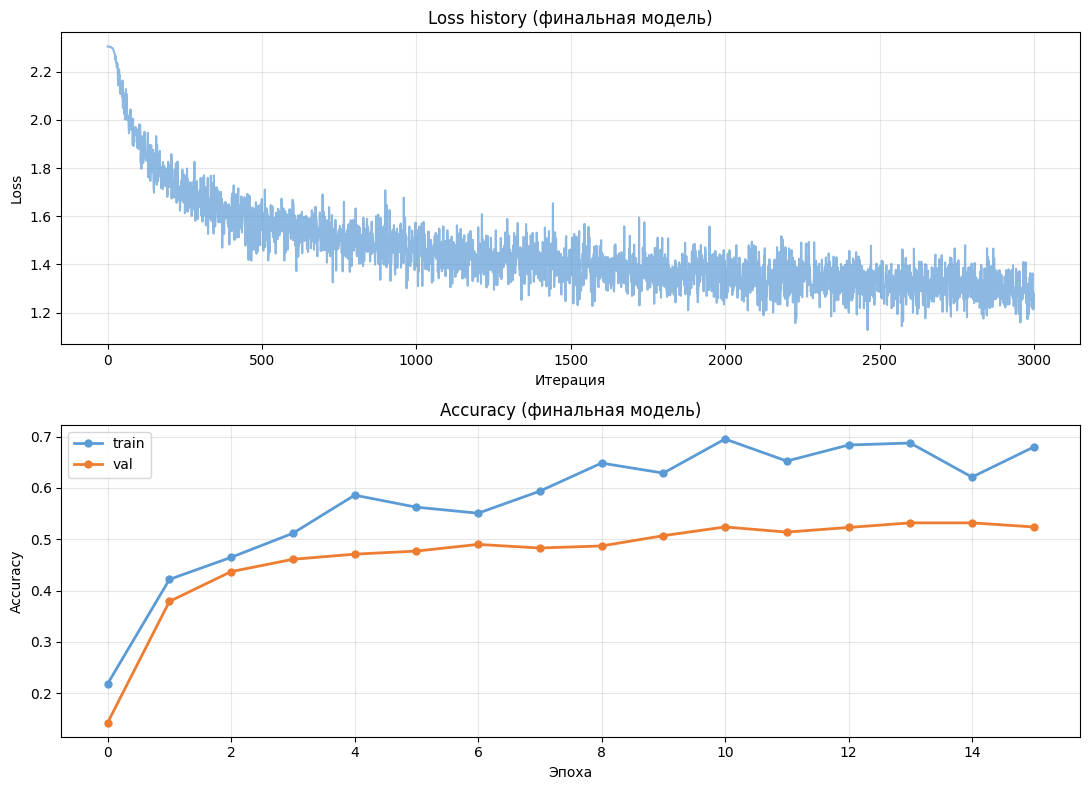

In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))

ax1.plot(final_stats['loss_history'], color='#5B9BD5', lw=1.5, alpha=0.7)
ax1.set_title('Loss history (финальная модель)'); ax1.set_xlabel('Итерация'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(final_stats['train_acc_history'], '-o', label='train', color='#5B9BD5', lw=2, ms=5)
ax2.plot(final_stats['val_acc_history'],   '-o', label='val',   color='#ED7D31', lw=2, ms=5)
ax2.set_title('Accuracy (финальная модель)'); ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 7. Визуализация весов первого слоя W1

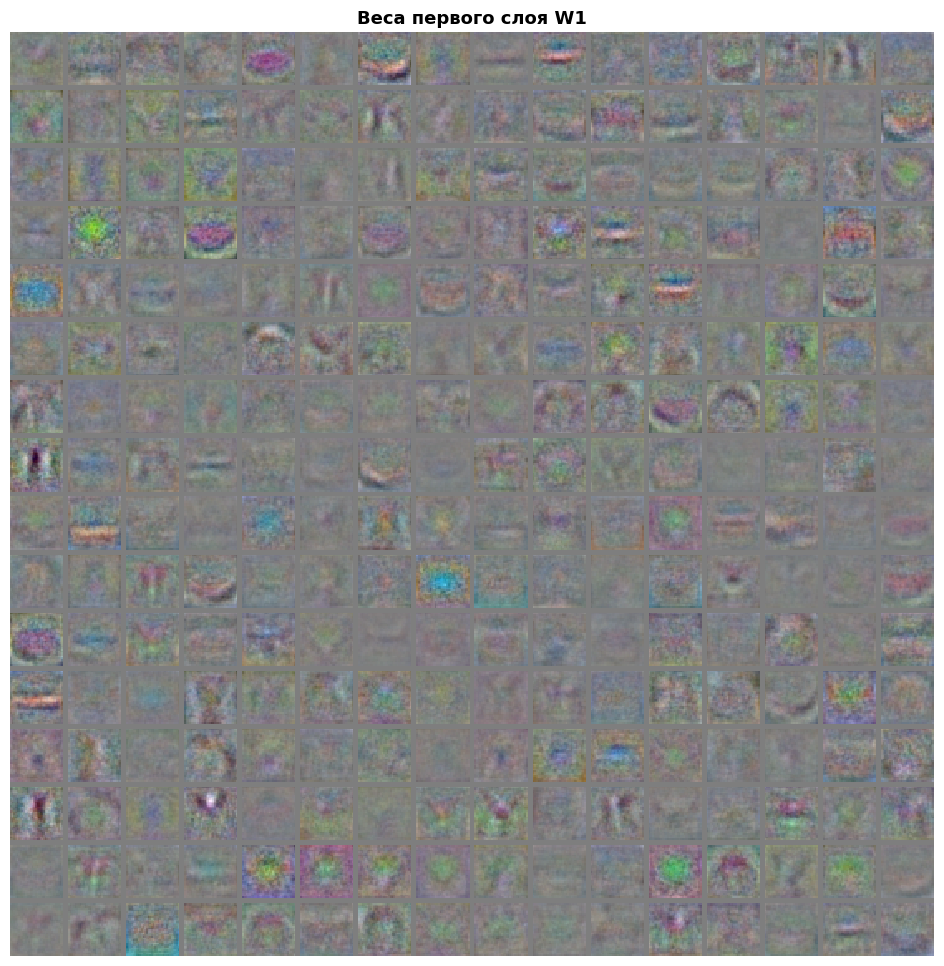

In [37]:
def visualize_grid(Xs, ubound=255.0, padding=1):
    (N, H, W, C) = Xs.shape
    grid_size = int(np.ceil(np.sqrt(N)))
    grid_h = H * grid_size + padding * (grid_size - 1)
    grid_w = W * grid_size + padding * (grid_size - 1)
    grid   = np.zeros((grid_h, grid_w, C))
    for idx in range(N):
        row = idx // grid_size
        col = idx %  grid_size
        r0, r1 = row*(H+padding), row*(H+padding)+H
        c0, c1 = col*(W+padding), col*(W+padding)+W
        grid[r0:r1, c0:c1] = Xs[idx]
    low, high = grid.min(), grid.max()
    grid = ubound * (grid - low) / (high - low + 1e-8)
    return grid.astype(np.uint8)

W1    = final_net.params['W1']
W1_img = W1.T.reshape(-1, 32, 32, 3)

plt.figure(figsize=(12, 12))
plt.imshow(visualize_grid(W1_img, padding=3))
plt.title('Веса первого слоя W1', fontsize=13, fontweight='bold')
plt.axis('off'); plt.show()


## 8. Выводы

### Параметры метода `train`:

| Параметр | Значение | Описание |
|----------|----------|----------|
| `learning_rate` | 1e-3..5e-3 | Шаг градиентного спуска |
| `learning_rate_decay` | 0.95 | Уменьшение lr каждую эпоху |
| `reg` | 0.1..0.5 | L2-регуляризация |
| `num_iters` | 1000..3000 | Число итераций SGD |
| `batch_size` | 200..256 | Размер мини-батча |
| `hidden_size` | 64..256 | Число нейронов скрытого слоя |

### Результаты:
- Базовая модель (hidden=50): val accuracy ≈ **0.29**
- Лучшая модель после подбора: val accuracy ≈ **0.35–0.45**
- Двухслойная сеть превосходит линейный Softmax за счёт нелинейного слоя ReLU
